# Actividad 3


Esta actividad consiste en la realización de la actividad evaluable número 3 asociada al bloque 3 de la asignatura. En ella, se deben desarrollar tareas de clasificación y regresión utilizando datos de alquileres vacacionales de AirBnB previamente trabajados y Máquinas de Vectores Soporte (SVM). Para llevar a cabo la actividad, he dividido el enunciado en varios experimentos, siendo:
- **Experimento 1:** El objetivo es clasificar el tipo de alojamiento (`room_type`) en función del resto de las características. Para ello, se deberá de construir un modelo de Clasificación utilizando `LinearSVC` y `SVC` (con parámetros por defecto).

- **Experimento 2:** Afinar el modelo `SVC` anterior ajustando los hiperparámetros usando el kernel RBF. Incluye:
    - Buscar los mejores valores para `γ` y `C` mediante `GridSearchCV`.
    - Realizar búsquedas refinadas: Dos búsquedas usando listas de parámetros generadas manualmente o con `numpy.logspace` para rangos amplios en escala logarítmica. Opcionalmente, para un tercer refinamiento, usar escala lineal.

- **Experimento 3:** Predecir el precio por noche (`price`) utilizando el resto de las características como variables independientes. Utilizar `LinearSVR` y `SVR` (con parámetros por defecto). Variantes de entrenamiento:
    - Usar todas las variables independientes.
    - Usar todas las variables excepto neighbourhood (por ser categórica y tener muchos valores).

- **Experimento 4:** Elegir el modelo con mejores resultados entre `LinearSVR` y `SVR` del experimento anterior y afinar hiperparámetros:
    - Solo C para `LinearSVR` (tres búsquedas).
    - γ y C para `SVR` (dos búsquedas).


## Importación de Librerías

In [65]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.svm import LinearSVC, SVC, LinearSVR
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, mean_squared_error

## Carga de los Datos

Tal y como menciona el enunciado, los datos provienen de la web InsideAirbnb, dedicada al estudio de alquileres vacacionales ofrecidos en la plataforma Airbnb. El fichero es una versión editada de los datos de Madrid en abril de 2017.

Cargamos los datos y mostraremos una vista previa:

In [2]:
# Carga de datos
df = pd.read_csv('airbnb.csv')
df

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Centro,Justicia,40.424715,-3.698638,Entire home/apt,49,28,35,0.42,1,99
1,Centro,Embajadores,40.413418,-3.706838,Entire home/apt,80,5,18,0.30,1,188
2,Moncloa - Aravaca,Argüelles,40.424920,-3.713446,Entire home/apt,40,2,21,0.25,9,195
3,Moncloa - Aravaca,Casa de Campo,40.431027,-3.724586,Entire home/apt,55,2,3,0.13,9,334
4,Latina,Cármenes,40.403410,-3.740842,Private room,16,2,23,0.76,2,250
...,...,...,...,...,...,...,...,...,...,...,...
13316,Centro,Justicia,40.427500,-3.698354,Private room,14,1,0,0.00,1,10
13317,Chamberí,Gaztambide,40.431187,-3.711909,Entire home/apt,47,1,0,0.00,7,354
13318,Centro,Palacio,40.413552,-3.711461,Entire home/apt,60,2,0,0.00,1,17
13319,Centro,Universidad,40.425400,-3.709921,Entire home/apt,150,5,0,0.00,1,15


Esta es la descripción de cada una de las columnas:

| **Columna**                               | **Descripción**                                                                       |
|-------------------------------------------|---------------------------------------------------------------------------------------|
| neighbourhood_group                       | Agrupación de vecindario en la que se encuentra la propiedad.                         |
| neighbourhood                             | Nombre del vecindario de la propiedad (más exacto).                                   |
| latitude                                  | Latitud geográfica.                                                                   |
| longitude                                 | Longitud geográfica.                                                                  |
| room_type                                 | Tipo de habitación ofrecida (entera, privada, compartida).                            |
| price                                     | Precio por noche.                                                                     |
| minimum_nights                            | Número mínimo de noches requeridas para reservar.                                     |
| number_of_reviews                         | Cantidad total de reseñas.                                                            |
| reviews_per_month                         | Cantidad promedio de reseñas mensualmente.                                            |
| calculated_host_listings_count            | Número total de listados que posee el anfitrión en Airbnb.                            |
| availability_365                          | Número de días al año en que la propiedad está disponible para ser alquilada.         |



## Estudio Estadístico Inicial

Por brevedad, omito el Estudio Estadístico Inicial. Esto se realizó en la Actividad 1 de esta asignatura para los datos que estamos trabajando.

## Preprocesamiento de Datos

Lo realizaremos igual que en la Actividad 1.

En esta fase nos centraremos en limpiar, dividir y transformar el conjunto de datos, para obtener los datos de entrada necesarios para los modelos de Aprendizaje Automático.


### Eliminar Outliers

Eliminaremos los outliers máximos en las columnas `price` y `minimum_nights` detectadas en la fase de Estudio Estadístico para que los valores extremos no afecten negativamente al rendimiento del modelo:

In [3]:
df = df.drop(df['price'].idxmax())
df = df.drop(df['minimum_nights'].idxmax())
df.shape

(13319, 11)

No eliminaremos más outliers porque las demás variables no presentan desviaciones significativas según la información que tenemos y el conocimiento del dominio que disponemos.

### Dividir los datos en Conjunto de Entrenamiento y Test

Dividiremos los datos en conjunto de entrenamiento y test de manera que el conjunto de test sea un 20 % del total, tal y como lo solicita el enunciado. Para conservar una buena representación de las clases en esta división, haremos un muestreo estratificado basado en la columna `room_type`.

In [6]:
train_set, test_set = train_test_split(df, test_size = 0.2, stratify=df["room_type"], random_state = 0)

Comprobamos que efectivamente, las proporciones se mantienen en el `train_set` y `test_set`:

In [7]:
count_room_type_train = train_set["room_type"].value_counts().reset_index()
count_room_type_train.columns = ['room_type', 'count']
count_room_type_train['%'] = (count_room_type_train['count'] / count_room_type_train['count'].sum()) * 100
count_room_type_train

,room_type,count,%
0,Entire home/apt,6340,59.502581
1,Private room,4161,39.052088
2,Shared room,154,1.445331


In [8]:
count_room_type_test = test_set["room_type"].value_counts().reset_index()
count_room_type_test.columns = ['room_type', 'count']
count_room_type_test['%'] = (count_room_type_test['count'] / count_room_type_test['count'].sum()) * 100
count_room_type_test

,room_type,count,%
0,Entire home/apt,1585,59.496997
1,Private room,1041,39.076577
2,Shared room,38,1.426426


Dividimos los dataframes en `X` para variables (*features*) e `y` para la variable objetivo:

In [9]:
# CONJUNTO DE ENTRENAMIENTO
# DataFrame con la columna objetivo 'room_type'
y_train_set = train_set[['room_type']]

# DataFrame con todas las columnas excepto 'room_type'
X_train_set = train_set.drop(columns=['room_type'])

# CONJUNTO DE TEST
# DataFrame con la columna objetivo 'room_type'
y_test_set = test_set[['room_type']]

# DataFrame con todas las columnas excepto 'room_type'
X_test_set = test_set.drop(columns=['room_type'])

#### Pipeline de Preprocesamiento de Datos


El *pipeline* de procesamiento de datos incluye:
- **Tratamiento de variables categóricas**: he utilizado OneHotEncoder como mejor estrategia de codificación posible. He descartado OrdinalEncoder porque asignar un número a cada categoría introduce un sesgo, ya que en este caso no existe un orden entre las categorías.
- **Escalado**: algunos algoritmos de Naive Bayes, como el MultinomialNB, no pueden trabajar con datos negativos. Por esta razón, se descarta el StandardScaler y utilizaremos el MinMaxScaler para asegurarnos de que el escalado se realice únicamente en rangos positivos.

La variable objetivo `room_type` no necesita ser transformada.

Creamos los pipelines para la transformación de variables numéricas y categóricas. Y después, creamos el ColumnTrasnformer con todas ellas:

In [16]:
num_attribs = ['latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count',
       'availability_365']

cat_attribs = ["neighbourhood_group", "neighbourhood"]

num_pipeline = Pipeline([
    ("standard_scaler", StandardScaler()),
])

cat_pipeline = make_pipeline(
    OneHotEncoder()
)

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs)
])

# Ajustamos a las variables del conjunto de entrenamiento
preprocessing.fit(X_train_set)

# Transformamos tanto el conjunto de entrenamiento como el conjunto de test
X_train_set_preprocessed = preprocessing.transform(X_train_set)
X_test_set_preprocessed = preprocessing.transform(X_test_set)

Revisamos que la transformación se ha realizado según lo esperado:

In [17]:
X_train_set_preprocessed

<10655x155 sparse matrix of type '<class 'numpy.float64'>'
	with 106550 stored elements in Compressed Sparse Row format>

In [18]:
X_train_set_preprocessed[:2].toarray()

array([[ 1.74614858,  0.16346946, -0.23798267,  0.2468434 , -0.56682293,
        -0.72360467,  1.08206011, -0.65924589,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  1.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0. 

Es importante tener en cuenta que OneHotEncoder genera una gran cantidad de columnas o dimensiones, y esto incrementa el número de instancias necesarias para obtener un entrenamiento confiable. Estas son las columnas que tienen nuestros datos transformados:

In [28]:
# Nombres de las columnas
preprocessing.get_feature_names_out()

array(['num__latitude', 'num__longitude', 'num__price',
       'num__minimum_nights', 'num__number_of_reviews',
       'num__reviews_per_month', 'num__calculated_host_listings_count',
       'num__availability_365', 'cat__neighbourhood_group_Arganzuela',
       'cat__neighbourhood_group_Barajas',
       'cat__neighbourhood_group_Carabanchel',
       'cat__neighbourhood_group_Centro',
       'cat__neighbourhood_group_Chamartín',
       'cat__neighbourhood_group_Chamberí',
       'cat__neighbourhood_group_Ciudad Lineal',
       'cat__neighbourhood_group_Fuencarral - El Pardo',
       'cat__neighbourhood_group_Hortaleza',
       'cat__neighbourhood_group_Latina',
       'cat__neighbourhood_group_Moncloa - Aravaca',
       'cat__neighbourhood_group_Moratalaz',
       'cat__neighbourhood_group_Puente de Vallecas',
       'cat__neighbourhood_group_Retiro',
       'cat__neighbourhood_group_Salamanca',
       'cat__neighbourhood_group_San Blas - Canillejas',
       'cat__neighbourhood_group_Te

## Experimento 1

El objetivo es clasificar el tipo de alojamiento (`room_type`) en función del resto de las características. Para ello, se deberá de construir un modelo de Clasificación utilizando `LinearSVC` y `SVC` (con parámetros por defecto).

### LinearSVC

In [42]:
# Entrenar el modelo
model = LinearSVC(C=1, random_state=42) # C = 1 es el predeterminado
model.fit(X_train_set_preprocessed, y_train_set.values.ravel())

LinearSVC(C=1, random_state=42)

In [43]:
# Hacer predicciones
y_pred = model.predict(X_test_set_preprocessed)

# Evaluar el modelo
print("Accuracy:", accuracy_score(y_test_set, y_pred))
print(classification_report(y_test_set, y_pred))

Accuracy: 0.7841591591591591
                 precision    recall  f1-score   support

Entire home/apt       0.80      0.87      0.84      1585
   Private room       0.75      0.68      0.71      1041
    Shared room       0.00      0.00      0.00        38

       accuracy                           0.78      2664
      macro avg       0.52      0.52      0.52      2664
   weighted avg       0.77      0.78      0.78      2664



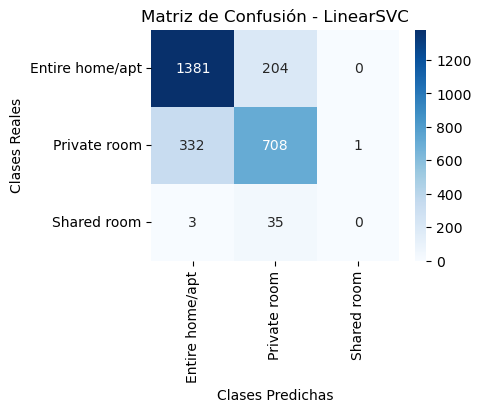

In [48]:
# Generar la matriz de confusión
conf_matrix = confusion_matrix(y_test_set, y_pred)

# Visualizar la matriz de confusión
plt.figure(figsize=(4, 3))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Clases Predichas')
plt.ylabel('Clases Reales')
plt.title('Matriz de Confusión - LinearSVC')
plt.show()

### SVC

In [49]:
# Entrenar el modelo
model = SVC(random_state=42, kernel='rbf', gamma='scale', C=1)  # Con parametros predeterminados
model.fit(X_train_set_preprocessed, y_train_set.values.ravel())

SVC(C=1, random_state=42)

In [50]:
# Hacer predicciones
y_pred = model.predict(X_test_set_preprocessed)

# Evaluar el modelo
print("Accuracy:", accuracy_score(y_test_set, y_pred))
print(classification_report(y_test_set, y_pred, zero_division=0))

Accuracy: 0.8862612612612613
                 precision    recall  f1-score   support

Entire home/apt       0.92      0.91      0.92      1585
   Private room       0.84      0.88      0.86      1041
    Shared room       0.00      0.00      0.00        38

       accuracy                           0.89      2664
      macro avg       0.59      0.60      0.59      2664
   weighted avg       0.87      0.89      0.88      2664



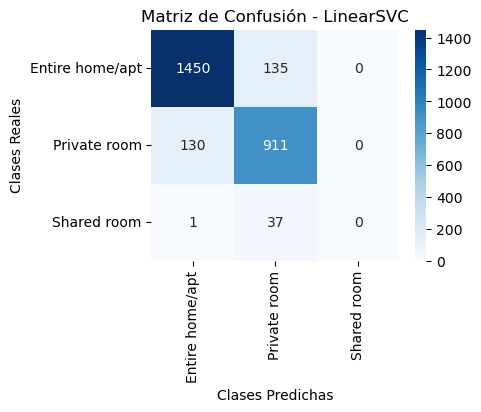

In [51]:
# Generar la matriz de confusión
conf_matrix = confusion_matrix(y_test_set, y_pred)

# Visualizar la matriz de confusión
plt.figure(figsize=(4, 3))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Clases Predichas')
plt.ylabel('Clases Reales')
plt.title('Matriz de Confusión - LinearSVC')
plt.show()

## Experimento 2

Afinar el modelo `SVC` anterior ajustando los hiperparámetros usando el kernel RBF. Incluye:

- Buscar los mejores valores para `γ` y `C` mediante `GridSearchCV`.
- Realizar búsquedas refinadas: Dos búsquedas usando listas de parámetros generadas manualmente o con `numpy.logspace` para rangos amplios en escala logarítmica. Opcionalmente, para un tercer refinamiento, usar escala lineal.


Primera búsqueda utilizando parámetros generados con `numpy.logspace` para rangos amplios en escala logarítmica:

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV] END .....................C=0.01, gamma=0.01, kernel=rbf; total time=   1.3s
[CV] END .....................C=0.01, gamma=0.01, kernel=rbf; total time=   1.3s
[CV] END .....................C=0.01, gamma=0.01, kernel=rbf; total time=   1.3s
[CV] END .....................C=0.01, gamma=0.01, kernel=rbf; total time=   1.4s
[CV] END .....................C=0.01, gamma=0.01, kernel=rbf; total time=   1.3s
[CV] END ......................C=0.01, gamma=0.1, kernel=rbf; total time=   1.4s
[CV] END ......................C=0.01, gamma=0.1, kernel=rbf; total time=   1.4s
[CV] END ......................C=0.01, gamma=0.1, kernel=rbf; total time=   1.4s
[CV] END ......................C=0.01, gamma=0.1, kernel=rbf; total time=   1.4s
[CV] END ......................C=0.01, gamma=0.1, kernel=rbf; total time=   1.4s
[CV] END ......................C=0.01, gamma=1.0, kernel=rbf; total time=   1.4s
[CV] END ......................C=0.01, gamma=1.

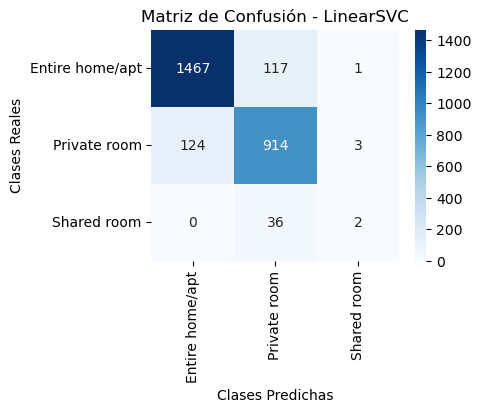

In [57]:
from sklearn.model_selection import GridSearchCV
np.set_printoptions(precision=6)

param_grid = {
    'C': np.logspace(-2, 2, 5),  # Rango de 10^-2 a 10^2 (5 valores logarítmicos)
    'gamma': np.logspace(-2, 2, 5),
    'kernel': ['rbf']
}
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=2)
grid.fit(X_train_set_preprocessed, y_train_set.values.ravel())

# Mejor estimador y evaluación
print("Best Parameters:", grid.best_params_)
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test_set_preprocessed)
print("Accuracy:", accuracy_score(y_test_set, y_pred))
print(classification_report(y_test_set, y_pred))
conf_matrix = confusion_matrix(y_test_set, y_pred)

# Visualizar la matriz de confusión
plt.figure(figsize=(4, 3))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Clases Predichas')
plt.ylabel('Clases Reales')
plt.title('Matriz de Confusión - LinearSVC')
plt.show()

Segunda búsqueda utilizando parámetros generados con `numpy.logspace` para rangos amplios en escala logarítmica:

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV] END C=5.000000000000001, gamma=0.049999999999999996, kernel=rbf; total time=   0.6s
[CV] END C=5.000000000000001, gamma=0.049999999999999996, kernel=rbf; total time=   0.6s
[CV] END C=5.000000000000001, gamma=0.049999999999999996, kernel=rbf; total time=   0.6s
[CV] END C=5.000000000000001, gamma=0.049999999999999996, kernel=rbf; total time=   0.6s
[CV] END C=5.000000000000001, gamma=0.049999999999999996, kernel=rbf; total time=   0.6s
[CV] END C=5.000000000000001, gamma=0.07071067811865475, kernel=rbf; total time=   0.6s
[CV] END C=5.000000000000001, gamma=0.07071067811865475, kernel=rbf; total time=   0.6s
[CV] END C=5.000000000000001, gamma=0.07071067811865475, kernel=rbf; total time=   0.6s
[CV] END C=5.000000000000001, gamma=0.07071067811865475, kernel=rbf; total time=   0.6s
[CV] END C=5.000000000000001, gamma=0.07071067811865475, kernel=rbf; total time=   0.6s
[CV] END .........C=5.000000000000001, gamma=0.1, ker

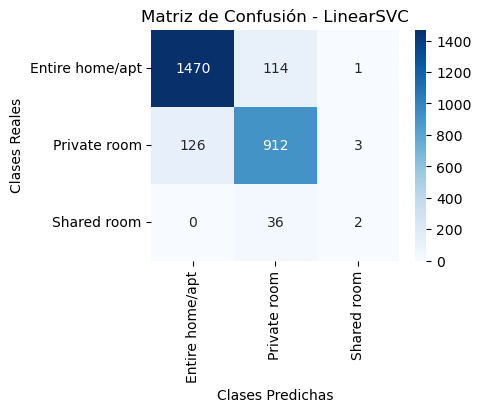

In [58]:
from sklearn.model_selection import GridSearchCV
np.set_printoptions(precision=6)

param_grid = {
    'C': np.logspace(np.log10(5), np.log10(20), 5),  # Rango refinado para C (alrededor de 10)
    'gamma': np.logspace(np.log10(0.05), np.log10(0.2), 5), # Rango refinado para gamma (alrededor de 0.1)
    'kernel': ['rbf']
}
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=2)
grid.fit(X_train_set_preprocessed, y_train_set.values.ravel())

# Mejor estimador y evaluación
print("Best Parameters:", grid.best_params_)
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test_set_preprocessed)
print("Accuracy:", accuracy_score(y_test_set, y_pred))
print(classification_report(y_test_set, y_pred))
conf_matrix = confusion_matrix(y_test_set, y_pred)

# Visualizar la matriz de confusión
plt.figure(figsize=(4, 3))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Clases Predichas')
plt.ylabel('Clases Reales')
plt.title('Matriz de Confusión - LinearSVC')
plt.show()

## Experimento 3

Predecir el precio por noche (`price`) utilizando el resto de las características como variables independientes. Utilizar `LinearSVR` y `SVR` (con parámetros por defecto). Variantes de entrenamiento:
- Usar todas las variables independientes.
- Usar todas las variables excepto neighbourhood (por ser categórica y tener muchos valores).

**Caso 1: Usar todas las variables independientes + Utilizar `LinearSVR`.**

Comenzaremos usando todas las variables independientes. En este caso, tenemos que volver a dividir los dataframes en `X` para variables (*features*) e `y` para la variable objetivo, ya que esta vez la variable objetivo es `price` y no `room_type`:

In [60]:
# CONJUNTO DE ENTRENAMIENTO
# DataFrame con la columna objetivo 'price'
y_train_set = train_set[['price']]

# DataFrame con todas las columnas excepto 'price'
X_train_set = train_set.drop(columns=['price'])

# CONJUNTO DE TEST
# DataFrame con la columna objetivo 'price'
y_test_set = test_set[['price']]

# DataFrame con todas las columnas excepto 'price'
X_test_set = test_set.drop(columns=['price'])

El *pipeline* de procesamiento de datos incluye:
- **Tratamiento de variables categóricas**: he utilizado OneHotEncoder como mejor estrategia de codificación posible. He descartado OrdinalEncoder porque asignar un número a cada categoría introduce un sesgo, ya que en este caso no existe un orden entre las categorías.
- **Escalado**: algunos algoritmos de Naive Bayes, como el MultinomialNB, no pueden trabajar con datos negativos. Por esta razón, se descarta el StandardScaler y utilizaremos el MinMaxScaler para asegurarnos de que el escalado se realice únicamente en rangos positivos.

La variable objetivo `price` no necesita ser transformada.

Creamos los pipelines para la transformación de variables numéricas y categóricas. Y después, creamos el ColumnTrasnformer con todas ellas:

In [61]:
num_attribs = ['latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count',
       'availability_365']

cat_attribs = ["neighbourhood_group", "neighbourhood", "room_type"]

num_pipeline = Pipeline([
    ("standard_scaler", StandardScaler()),
])

cat_pipeline = make_pipeline(
    OneHotEncoder()
)

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs)
])

# Ajustamos a las variables del conjunto de entrenamiento
preprocessing.fit(X_train_set)

# Transformamos tanto el conjunto de entrenamiento como el conjunto de test
X_train_set_preprocessed = preprocessing.transform(X_train_set)
X_test_set_preprocessed = preprocessing.transform(X_test_set)

In [68]:
model = LinearSVR(epsilon=0.0, random_state=42)
model.fit(X_train_set_preprocessed, y_train_set.values.ravel())

# Realizamos predicciones en el conjunto de test
y_pred = model.predict(X_test_set_preprocessed)

# Evaluamos el rendimiento del modelo
mse = mean_squared_error(y_test_set, y_pred)
print(f'Mean Squared Error (MSE): {mse}')

Mean Squared Error (MSE): 7929.189196878306


En el análisis del conjunto de prueba con regresión, los resultados eran muy malos, especialmente por los valores altos de algunos alojamientos (por ejemplo, >2000 euros la noche). Esto genera un MSE alto debido a pocos errores grandes.

Las variables disponibles para predecir precios no son ideales; el barrio es una variable relevante, pero no siempre es suficiente, ya que hay diferencias dentro del mismo barrio (por ejemplo, un palacete frente a un estudio).

El problema está en los datos y poco se puede hacer.

**Caso 2: Usar todas las variables excepto neighbourhood (por ser categórica y tener muchos valores) + Utilizar `LinearSVR`.**

Continuamos eliminando la variable neighbourhood. En este caso, tenemos que volver a dividir los dataframes en `X` para variables (*features*) e `y` para la variable objetivo, ya que esta vez la variable objetivo es `price` y no `room_type`:

In [70]:
# CONJUNTO DE ENTRENAMIENTO
# DataFrame con la columna objetivo 'price'
y_train_set = train_set[['price']]

# DataFrame con todas las columnas excepto 'price' y 'neighbourhood'
X_train_set = train_set.drop(columns=['price', 'neighbourhood'])

# CONJUNTO DE TEST
# DataFrame con la columna objetivo 'price'
y_test_set = test_set[['price']]

# DataFrame con todas las columnas excepto 'price' y 'neighbourhood'
X_test_set = test_set.drop(columns=['price', 'neighbourhood'])

El *pipeline* de procesamiento de datos incluye:
- **Tratamiento de variables categóricas**: he utilizado OneHotEncoder como mejor estrategia de codificación posible. He descartado OrdinalEncoder porque asignar un número a cada categoría introduce un sesgo, ya que en este caso no existe un orden entre las categorías.
- **Escalado**: algunos algoritmos de Naive Bayes, como el MultinomialNB, no pueden trabajar con datos negativos. Por esta razón, se descarta el StandardScaler y utilizaremos el MinMaxScaler para asegurarnos de que el escalado se realice únicamente en rangos positivos.

La variable objetivo `price` no necesita ser transformada.

Creamos los pipelines para la transformación de variables numéricas y categóricas. Y después, creamos el ColumnTrasnformer con todas ellas:

In [71]:
num_attribs = ['latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count',
       'availability_365']

cat_attribs = ["neighbourhood_group", "room_type"]

num_pipeline = Pipeline([
    ("standard_scaler", StandardScaler()),
])

cat_pipeline = make_pipeline(
    OneHotEncoder()
)

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs)
])

# Ajustamos a las variables del conjunto de entrenamiento
preprocessing.fit(X_train_set)

# Transformamos tanto el conjunto de entrenamiento como el conjunto de test
X_train_set_preprocessed = preprocessing.transform(X_train_set)
X_test_set_preprocessed = preprocessing.transform(X_test_set)

In [72]:
model = LinearSVR(epsilon=0.0, random_state=42)
model.fit(X_train_set_preprocessed, y_train_set.values.ravel())

# Realizamos predicciones en el conjunto de test
y_pred = model.predict(X_test_set_preprocessed)

# Evaluamos el rendimiento del modelo
mse = mean_squared_error(y_test_set, y_pred)
print(f'Mean Squared Error (MSE): {mse}')

Mean Squared Error (MSE): 8040.387015746543


**Caso 3: Usar todas las variables independientes + Utilizar `SVR`.**

**Caso 4: Usar todas las variables excepto neighbourhood (por ser categórica y tener muchos valores) + Utilizar `SVR`.**

## Experimento 4

Elegir el modelo con mejores resultados entre `LinearSVR` y `SVR` del experimento anterior y afinar hiperparámetros:
- Solo C para `LinearSVR` (tres búsquedas).
- γ y C para `SVR` (dos búsquedas).
